In [170]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier,XGBRegressor
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay,accuracy_score
import shap
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [52]:
df=pd.read_csv("/kaggle/input/datasets/abdelazizsami/predictive-maintenance-dataset/ai 2020.csv")

In [53]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [54]:
df.tail()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0
9999,10000,M24859,M,299.0,308.7,1500,40.2,30,0,0,0,0,0,0


In [55]:
df.shape

(10000, 14)

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [57]:
df.dtypes

UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

In [58]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [59]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [60]:
df.duplicated().sum()

np.int64(0)

In [61]:
df=df.drop(columns=['UDI','Product ID'])

In [62]:
df['Type'].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

In [63]:
df['Machine failure'].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

<Axes: >

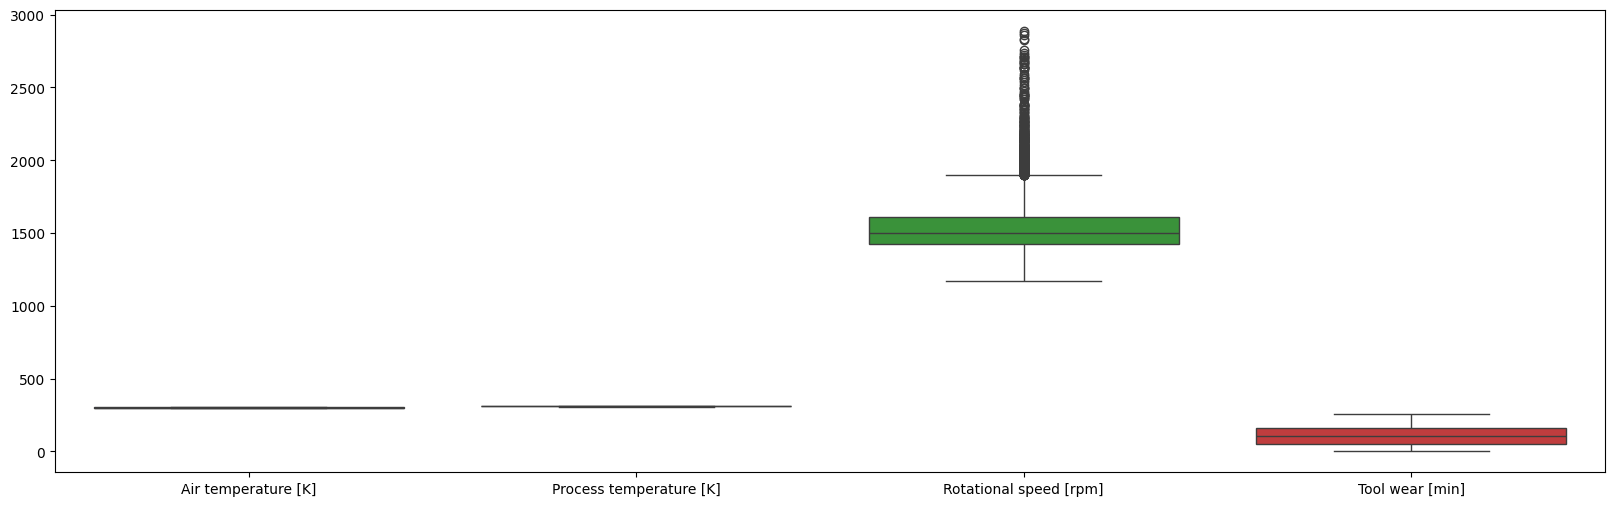

In [64]:
num_df=df[['Air temperature [K]','Process temperature [K]','Rotational speed [rpm]','Tool wear [min]']]
plt.figure(figsize=(20,6))
sns.boxplot(num_df)

In [65]:
df['Rotational speed [rpm]_log']=np.log1p(df['Rotational speed [rpm]'])

<Axes: >

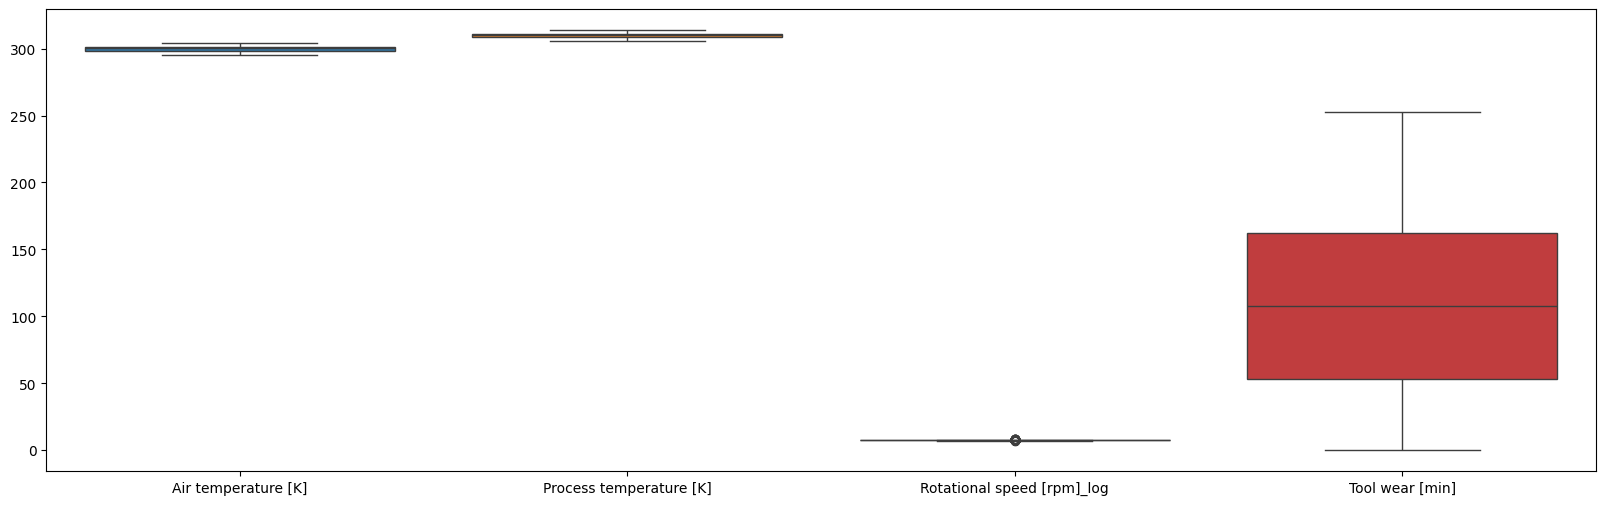

In [66]:
num_df=df[['Air temperature [K]','Process temperature [K]','Rotational speed [rpm]_log','Tool wear [min]']]
plt.figure(figsize=(20,6))
sns.boxplot(num_df)

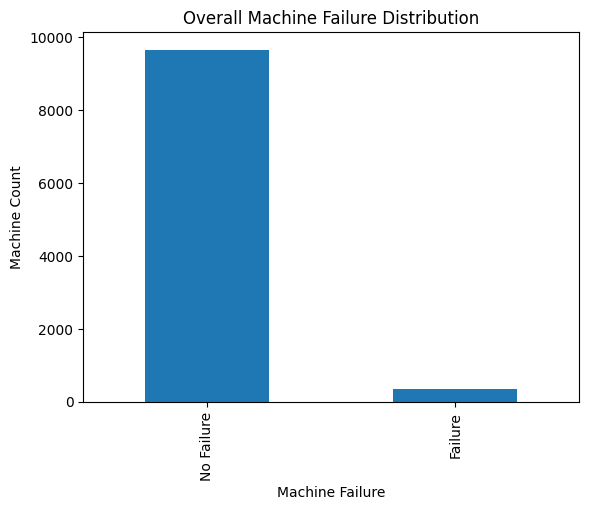

In [67]:
ax = df['Machine failure'].value_counts().plot(kind='bar')
ax.set_xticklabels(['No Failure', 'Failure'])
plt.xlabel("Machine Failure")
plt.ylabel("Machine Count")
plt.title("Overall Machine Failure Distribution")
plt.show()

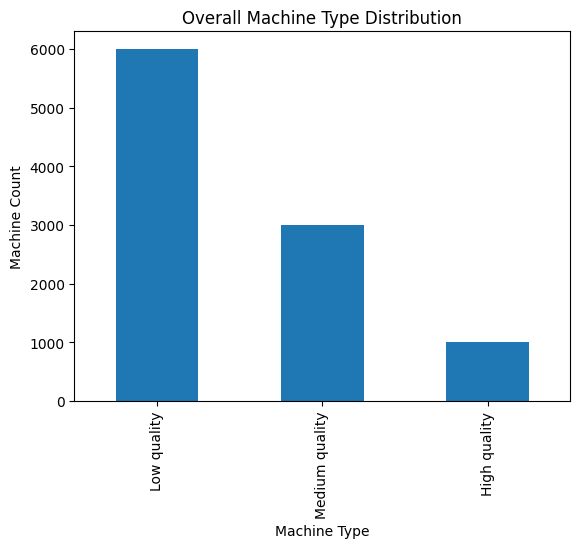

In [68]:
a = df['Type'].value_counts().plot(kind='bar')
a.set_xticklabels(['Low quality','Medium quality','High quality'])
plt.xlabel("Machine Type")
plt.ylabel("Machine Count")
plt.title("Overall Machine Type Distribution")
plt.show()

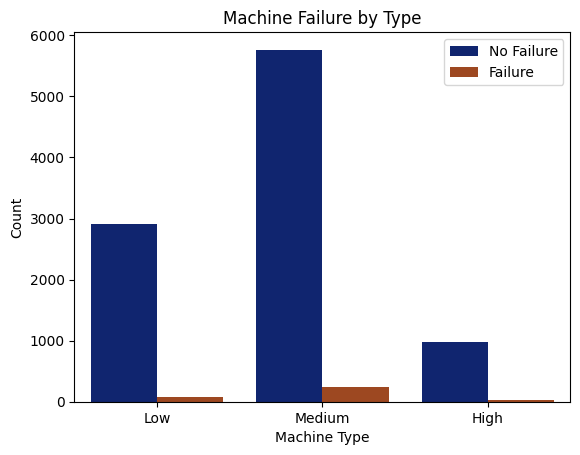

In [69]:
ax = sns.countplot(x='Type', hue='Machine failure', data=df,palette='dark')
ax.set_xticklabels(['Low', 'Medium', 'High'])
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['No Failure', 'Failure'])
plt.xlabel("Machine Type")
plt.ylabel("Count")
plt.title("Machine Failure by Type")
plt.show()

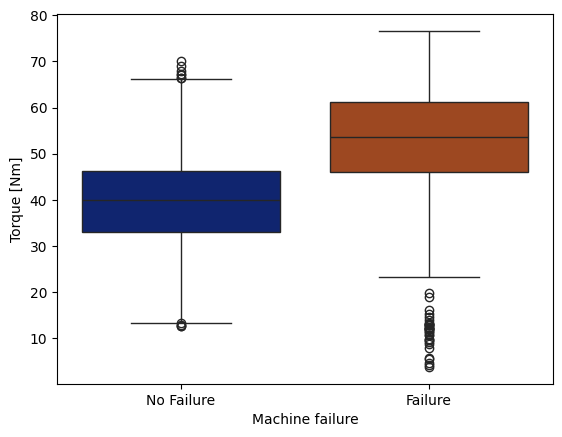

In [70]:
ax=sns.boxplot(x='Machine failure', y='Torque [Nm]', data=df,palette='dark')
ax.set_xticklabels(['No Failure', 'Failure'])
plt.show()

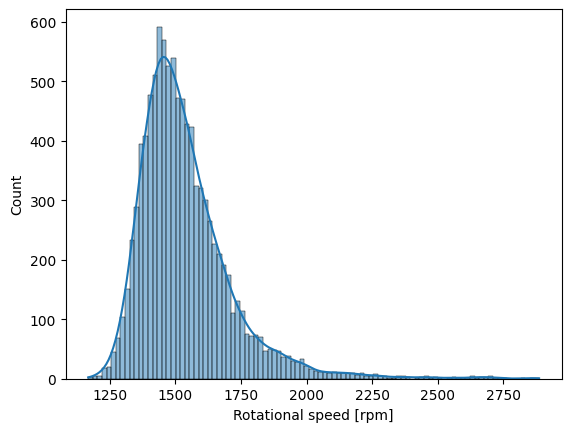

In [71]:
sns.histplot(df['Rotational speed [rpm]'], kde=True)
plt.show()

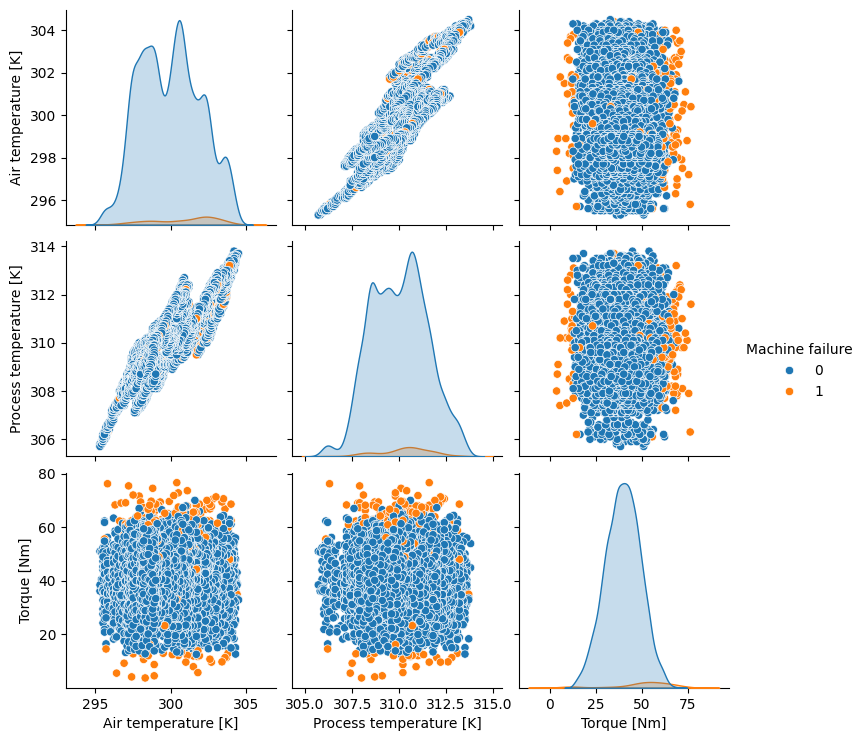

In [72]:
ax=sns.pairplot(df[['Air temperature [K]',
                 'Process temperature [K]',
                 'Torque [Nm]',
                 'Machine failure']], hue='Machine failure')
plt.show()

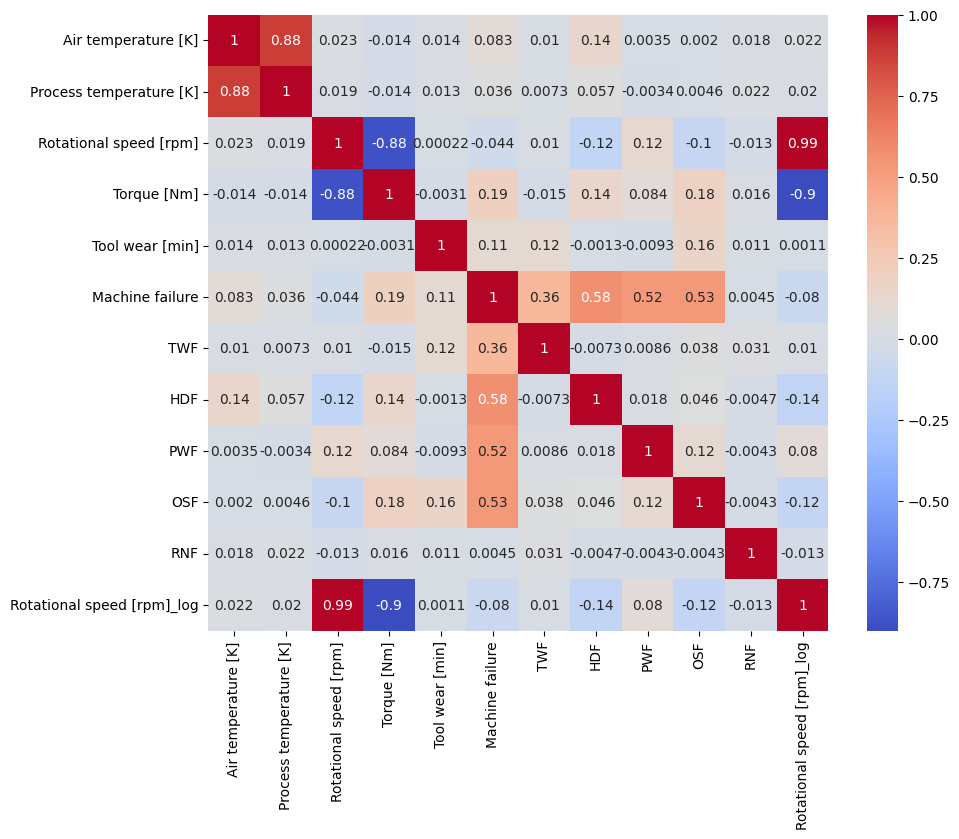

In [73]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [74]:
df.columns = df.columns.str.replace('[', '', regex=False)
df.columns = df.columns.str.replace(']', '', regex=False)
df.columns = df.columns.str.replace('<', '', regex=False)
df.columns = df.columns.str.replace(' ', '_')

In [75]:
obj=df.select_dtypes(include='object')
obj

,Type
0,M
1,L
2,L
3,L
4,L
...,...
9995,M
9996,H
9997,M
9998,H


In [76]:
df1=df.copy()
le=LabelEncoder()

In [77]:
df1=pd.get_dummies(df1,columns=['Type'])

In [78]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Air_temperature_K         10000 non-null  float64
 1   Process_temperature_K     10000 non-null  float64
 2   Rotational_speed_rpm      10000 non-null  int64  
 3   Torque_Nm                 10000 non-null  float64
 4   Tool_wear_min             10000 non-null  int64  
 5   Machine_failure           10000 non-null  int64  
 6   TWF                       10000 non-null  int64  
 7   HDF                       10000 non-null  int64  
 8   PWF                       10000 non-null  int64  
 9   OSF                       10000 non-null  int64  
 10  RNF                       10000 non-null  int64  
 11  Rotational_speed_rpm_log  10000 non-null  float64
 12  Type_H                    10000 non-null  bool   
 13  Type_L                    10000 non-null  bool   
 14  Type_M 

In [79]:
df1=df1.drop(columns=['Rotational_speed_rpm_log'])

In [80]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Air_temperature_K      10000 non-null  float64
 1   Process_temperature_K  10000 non-null  float64
 2   Rotational_speed_rpm   10000 non-null  int64  
 3   Torque_Nm              10000 non-null  float64
 4   Tool_wear_min          10000 non-null  int64  
 5   Machine_failure        10000 non-null  int64  
 6   TWF                    10000 non-null  int64  
 7   HDF                    10000 non-null  int64  
 8   PWF                    10000 non-null  int64  
 9   OSF                    10000 non-null  int64  
 10  RNF                    10000 non-null  int64  
 11  Type_H                 10000 non-null  bool   
 12  Type_L                 10000 non-null  bool   
 13  Type_M                 10000 non-null  bool   
dtypes: bool(3), float64(3), int64(8)
memory usage: 888.8 KB

In [81]:
df1['Failure_Type'] = 'No_Failure'

df1.loc[df1['TWF'] == 1, 'Failure_Type'] = 'Tool_Wear_Failure'
df1.loc[df1['HDF'] == 1, 'Failure_Type'] = 'Heat_Dissipation_Failure'
df1.loc[df1['PWF'] == 1, 'Failure_Type'] = 'Power_Failure'
df1.loc[df1['OSF'] == 1, 'Failure_Type'] = 'Overstrain_Failure'
df1.loc[df1['RNF'] == 1, 'Failure_Type'] = 'Random_Failure'

In [121]:
X=df1[['Type_H',
       'Type_L',
       'Type_M',
        'Air_temperature_K',
        'Process_temperature_K',
        'Rotational_speed_rpm',
        'Torque_Nm',
        'Tool_wear_min']]
Y_cls=df1['Failure_Type']

In [123]:
y = le.fit_transform(df1['Failure_Type'])

In [131]:
X_train,X_test,Y_train,Y_test=train_test_split(X,y,test_size=0.2,stratify=y)

In [133]:
X_train.shape

(8000, 8)

In [134]:
X_test.shape

(2000, 8)

In [135]:
Y_train.shape

(8000,)

In [136]:
Y_test.shape

(2000,)

In [137]:
xg = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=1,
    gamma=0.1,
    min_child_weight=3,
    random_state=42,
    class_weight='balanced'
)
xg.fit(X_train,Y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              class_weight='balanced', colsample_bylevel=None,
              colsample_bynode=None, colsample_bytree=0.9, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=0.1, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None, ...)

In [138]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(xg,X,y,cv=skf)
print(scores)
print(scores.mean())

[0.988  0.9835 0.984  0.986  0.985 ]
0.9853


In [140]:
y_pred2=xg.predict(X_test)

In [141]:
y_proba=xg.predict_proba(X_test)[:,1]

In [142]:
y_pred2=(y_proba>0.6).astype(int)

In [143]:
print(classification_report(Y_test,y_pred2))

              precision    recall  f1-score   support

           0       0.35      0.95      0.51        21
           1       0.99      1.00      0.99      1930
           2       0.00      0.00      0.00        20
           3       0.00      0.00      0.00        17
           4       0.00      0.00      0.00         4
           5       0.00      0.00      0.00         8

    accuracy                           0.97      2000
   macro avg       0.22      0.32      0.25      2000
weighted avg       0.96      0.97      0.96      2000



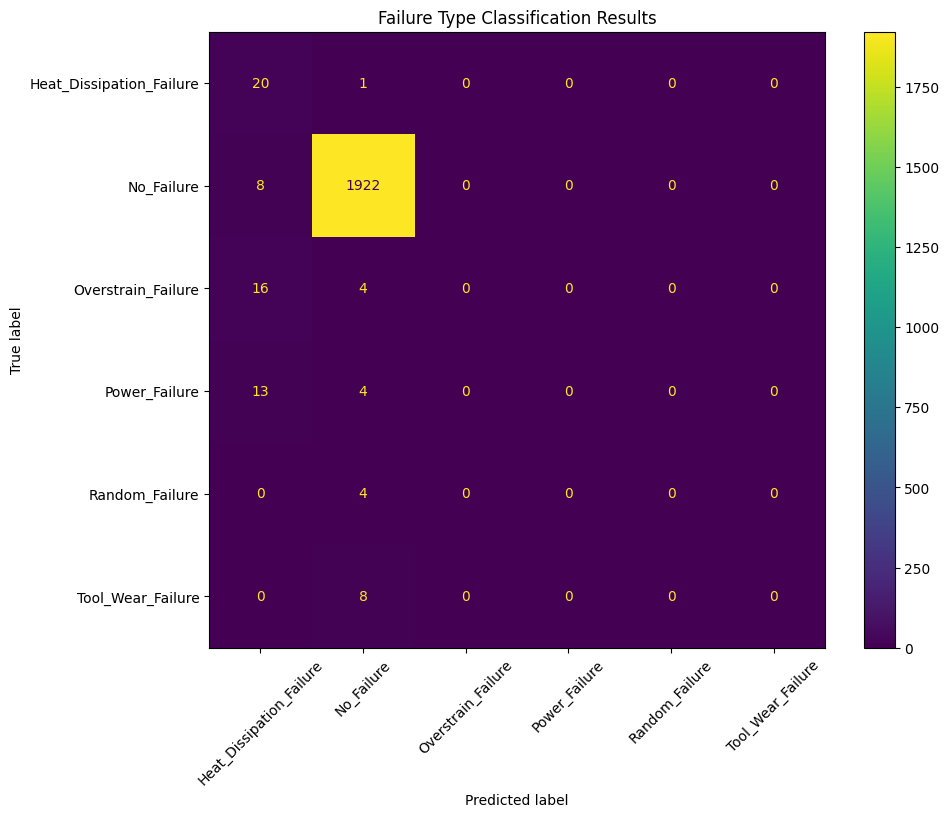

In [144]:
cm=confusion_matrix(Y_test,y_pred2)
class_names = le.classes_ 
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='viridis', ax=ax, xticks_rotation=45)
plt.title("Failure Type Classification Results")
plt.show()

In [145]:
explainer=shap.TreeExplainer(xg)

In [146]:
shap_values=explainer(X_test)

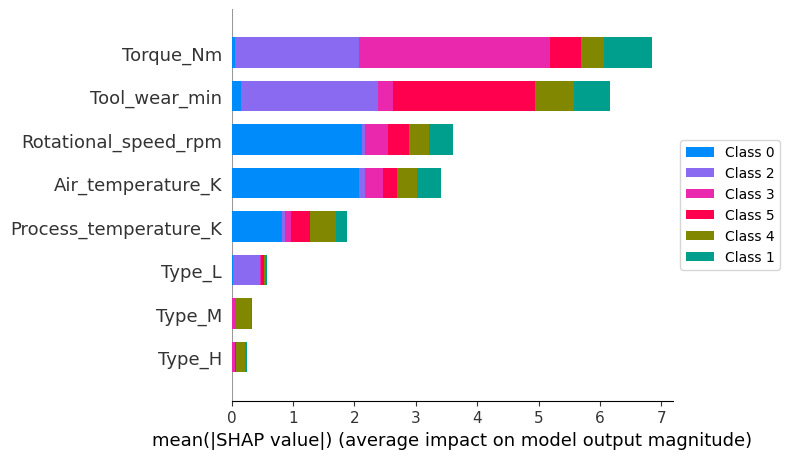

In [155]:
shap.summary_plot(shap_values, X, show=False)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1) 
plt.tight_layout()
plt.show()

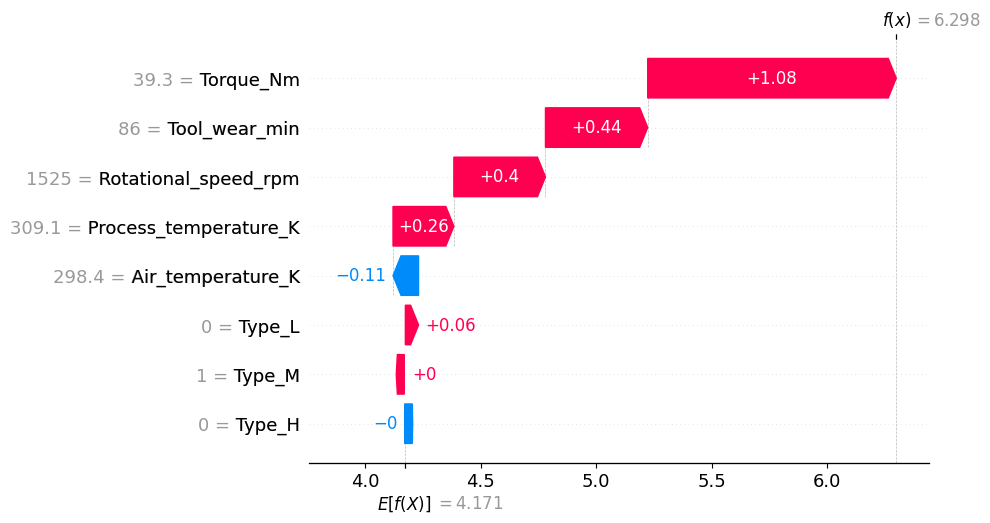

In [115]:
shap.plots.waterfall(shap_values[0][:, 1])

In [206]:
df_failures = df1[df1['Failure_Type'] != 0].copy()

In [208]:
df_failures['RUL'] = df_failures['Tool_wear_min'].max()- df_failures['Tool_wear_min']

In [209]:
X_reg = df_failures[['Type_H', 'Type_L', 'Type_M', 'Air_temperature_K', 
                     'Process_temperature_K', 'Rotational_speed_rpm', 
                     'Torque_Nm', 'Tool_wear_min']]
y_reg = df_failures['RUL']

In [214]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

In [215]:
reg = XGBRegressor(
    n_estimators=200,   
    max_depth=10,        
    learning_rate=0.05, 
    objective='reg:squarederror',
    random_state=42
)
reg.fit(X_train_reg, y_train_reg)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [217]:
y_pred = reg.predict(X_test)

In [218]:
mae = mean_absolute_error(y_test_reg, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))
r2 = r2_score(y_test_reg, y_pred)
print(f"Mean Absolute Error (MAE): {mae:.2f} minutes")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} minutes")
print(f"R2 Score: {r2:.4f}")

Mean Absolute Error (MAE): 0.00 minutes
Root Mean Squared Error (RMSE): 0.06 minutes
R2 Score: 1.0000


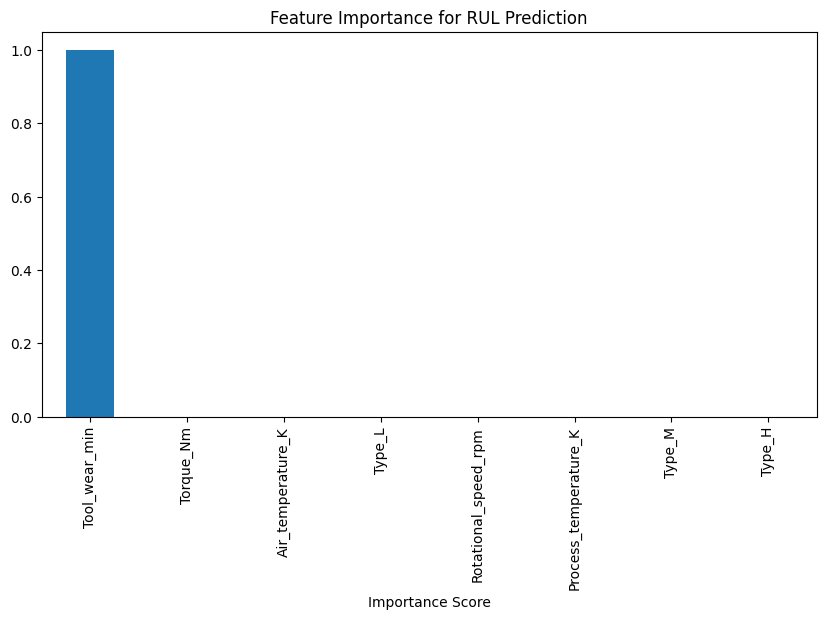

In [219]:
plt.figure(figsize=(10, 5))
feat= pd.Series(reg.feature_importances_, index=X.columns)
feat.nlargest(8).plot(kind='bar')
plt.title('Feature Importance for RUL Prediction')
plt.xlabel('Importance Score')
plt.show()

In [221]:
df_failures_2= df1[df1['Failure_Type'] != 0].copy()

In [223]:
X_v2 = df_failures_2[['Type_H', 'Type_L', 'Type_M', 'Air_temperature_K', 
                  'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm']]
y_v2 = df_failures_2['RUL']

In [224]:
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(X_v2, y_v2, test_size=0.2, random_state=42)

In [225]:
reg_v2 = XGBRegressor(
    n_estimators=200, 
    max_depth=8, 
    learning_rate=0.05, 
    objective='reg:squarederror'
)

reg_v2.fit(X_train_v2, y_train_v2)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [227]:
y_pred_v2 = reg_v2.predict(X_test_v2)

In [233]:
print(f"MAE: {mean_absolute_error(y_test_v2, y_pred_v2):.2f} minutes")
print(f"R2 Score: {r2_score(y_test_v2, y_pred_v2):.4f}")

MAE: 52.40 minutes
R2 Score: 0.0773


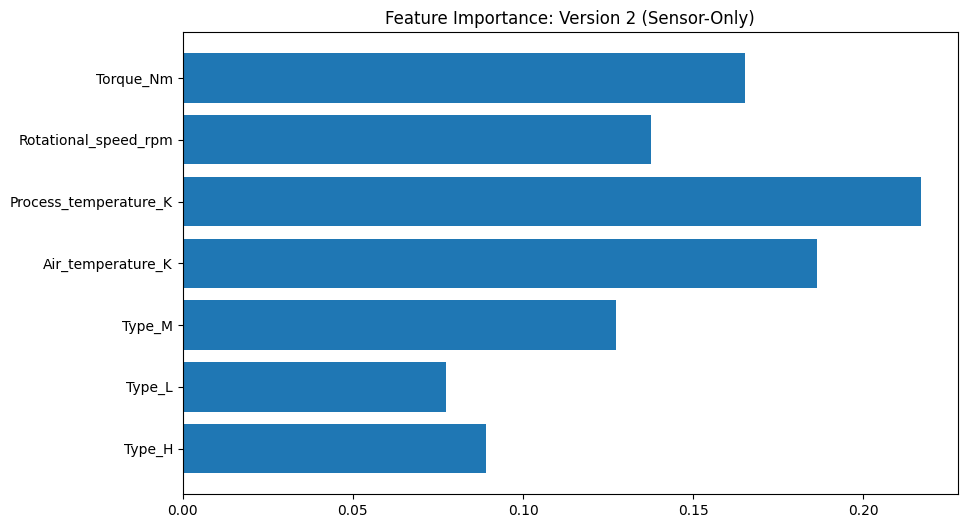

In [230]:
plt.figure(figsize=(10, 6))
imp = reg_v2.feature_importances_
plt.barh(X_v2.columns, imp)
plt.title('Feature Importance: Version 2 (Sensor-Only)')
plt.show()

In [238]:
test_input = [0, 0, 1, 298.1, 308.6, 1551, 42.8, 180] 
sample = np.array([test_input])
class_idx = xg.predict(sample)
failure_name = le.inverse_transform(class_idx)[0]
if failure_name != "No Failure":
    time_remaining = reg.predict(sample)[0]
    time_output = f"{round(float(time_remaining), 2)} Minutes"
else:
    time_output = "Machine is Healthy"

In [257]:
print(f"--- Machine Analysis ---")
print(f"Predicted Status: {failure_name}")
print(f"Remaining Life: {time_output}")

--- Machine Analysis ---
Predicted Status: No_Failure
Remaining Life: 73.0 Minutes


In [258]:
explainer = shap.TreeExplainer(xg)
raw_shap_values = explainer.shap_values(sample_input)
reshaped_shap = raw_shap_values.reshape(6, 8) 
current_shap = reshaped_shap[pred_idx]
feat_names = ['Type_H', 'Type_L', 'Type_M', 'Air_T', 'Proc_T', 'RPM', 'Torque', 'Tool_Wear']
print(f"New reshaped SHAP length: {len(current_shap)}") # Should now be 8!

New reshaped SHAP length: 8


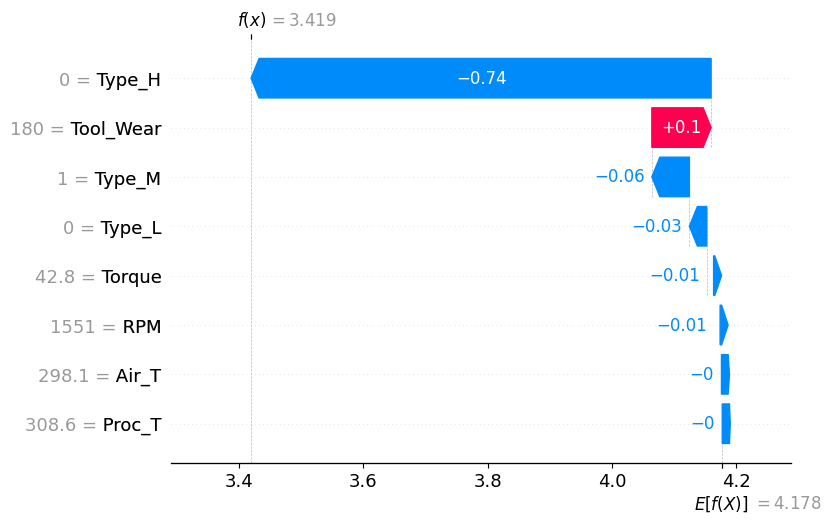

In [261]:
exp = shap.Explanation(
    values=current_shap,
    base_values=explainer.expected_value[pred_idx],
    data=sample_input.flatten(),
    feature_names=feat_names
)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(exp)